In [ ]:
import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Sequential, layers
import xlrd
import scipy.stats as stats

In [ ]:
import numpy as np
import scipy.stats as stats

# Ejemplo de datos
datos = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 100])

# Calcular la media usando NumPy
media = np.mean(datos)
print(f"Media: {media}")

# Calcular la mediana usando NumPy
mediana = np.median(datos)
print(f"Mediana: {mediana}")

# Calcular la desviación estándar usando NumPy
desviacion_estandar = np.std(datos)
print(f"Desviación estándar: {desviacion_estandar}")

# Calcular la varianza usando NumPy
varianza = np.var(datos)
print(f"Varianza: {varianza}")

# Calcular la curtosis usando SciPy
# SciPy ofrece diferentes tipos de curtosis. Por defecto, usa la curtosis fisher (exceso).
# Para la curtosis pearson (momento), puedes usar `bias=False` y `fisher=False` si es necesario.
curtosis = stats.kurtosis(datos)
print(f"Curtosis (Fisher): {curtosis}")

# Para la curtosis tipo Pearson (sin exceso, y sin ajuste por sesgo para una muestra)
curtosis_pearson = stats.kurtosis(datos, fisher=False, bias=False)
print(f"Curtosis (Pearson, sin exceso): {curtosis_pearson}")


### Explicación de las funciones:

*   **`np.mean(datos)`**: Calcula la media aritmética de los elementos en un array.
*   **`np.median(datos)`**: Calcula la mediana de los elementos en un array.
*   **`np.std(datos)`**: Calcula la desviación estándar de los elementos en un array. Por defecto, usa un divisor `N`.
*   **`np.var(datos)`**: Calcula la varianza de los elementos en un array. Por defecto, usa un divisor `N`.
*   **`stats.kurtosis(datos)`**: Calcula la curtosis de los datos. Esta función pertenece a la librería `scipy.stats`. Por defecto, calcula la curtosis de *exceso* (Fisher), donde un valor de 0 corresponde a una distribución normal. Si quieres la curtosis de *momento* (Pearson), debes usar el parámetro `fisher=False`.

Estas son solo algunas de las muchas funciones estadísticas disponibles en NumPy y SciPy. Ambas librerías son muy potentes para el análisis de datos.


**Clonación del Github**

In [ ]:
!git clone https://github.com/samuel2005wq/IMU_IABO

Cloning into 'IMU_IABO'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 14 (delta 1), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 403.56 KiB | 36.69 MiB/s, done.
Resolving deltas: 100% (1/1), done.


**Lectura de los Excel**

In [ ]:
df_izq = pd.read_excel('IMU_IABO/Datos/izquierda.xlsx',header=None)
df_der = pd.read_excel('IMU_IABO/Datos/derecha.xlsx',header=None)
df_arr = pd.read_excel('IMU_IABO/Datos/arriba.xlsx',header=None)
df_aba = pd.read_excel('IMU_IABO/Datos/abajo.xlsx',header=None)
df = pd.read_excel('IMU_IABO/Datos/default.xlsx',header=None)


In [ ]:
N=10.0                      # Número de muestras
nV=np.array(np.shape(ax))   # Número de muestras de la señal
segment = np.floor(nV/N)    # Número de segmetos de la señal
print("Segmentos : ",segment)

Segmentos :  [136.]


**Varianza y Media para estado quieto**

In [ ]:
# Lectura de las variables de la IMU
ax=df[0]
ay=df[1]
az=df[2]
gx=df[3]
gy=df[4]
gz=df[5]

#Inicializar las ventanas
var_ventana_axquieto=[]
var_ventana_ayquieto=[]
var_ventana_azquieto=[]
var_ventana_gxquieto=[]
var_ventana_gyquieto=[]
var_ventana_gzquieto=[]

med_ventana_axquieto=[]
med_ventana_ayquieto=[]
med_ventana_azquieto=[]
med_ventana_gxquieto=[]
med_ventana_gyquieto=[]
med_ventana_gzquieto=[]

for i in range (1,int(segment)):
  ventana_axPA=ax[int(i*N):int((i+1)*N)]
  ventana_ayPA=ay[int(i*N):int((i+1)*N)]
  ventana_azPA=az[int(i*N):int((i+1)*N)]
  ventana_gxPA=gx[int(i*N):int((i+1)*N)]
  ventana_gyPA=gy[int(i*N):int((i+1)*N)]
  ventana_gzPA=gz[int(i*N):int((i+1)*N)]
  var_ventana_axquieto.append(np.var(ventana_axPA))
  var_ventana_ayquieto.append(np.var(ventana_ayPA))
  var_ventana_azquieto.append(np.var(ventana_azPA))
  var_ventana_gxquieto.append(np.var(ventana_gxPA))
  var_ventana_gyquieto.append(np.var(ventana_gyPA))
  var_ventana_gzquieto.append(np.var(ventana_gzPA))

  med_ventana_axquieto.append(np.mean(ventana_axPA))
  med_ventana_ayquieto.append(np.mean(ventana_ayPA))
  med_ventana_azquieto.append(np.mean(ventana_azPA))
  med_ventana_gxquieto.append(np.mean(ventana_gxPA))
  med_ventana_gyquieto.append(np.mean(ventana_gyPA))
  med_ventana_gzquieto.append(np.mean(ventana_gzPA))

/tmp/ipython-input-2458767982.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in range (1,int(segment)):


**Varianza y Media para estado arriba**

In [ ]:
# Lectura de las variables de la IMU
ax=df_arr[0]
ay=df_arr[1]
az=df_arr[2]
gx=df_arr[3]
gy=df_arr[4]
gz=df_arr[5]

#Inicializar las ventanas
var_ventana_axarriba=[]
var_ventana_ayarriba=[]
var_ventana_azarriba=[]
var_ventana_gxarriba=[]
var_ventana_gyarriba=[]
var_ventana_gzarriba=[]

med_ventana_axarriba=[]
med_ventana_ayarriba=[]
med_ventana_azarriba=[]
med_ventana_gxarriba=[]
med_ventana_gyarriba=[]
med_ventana_gzarriba=[]

for i in range (1,int(segment)):
  ventana_axPA=ax[int(i*N):int((i+1)*N)]
  ventana_ayPA=ay[int(i*N):int((i+1)*N)]
  ventana_azPA=az[int(i*N):int((i+1)*N)]
  ventana_gxPA=gx[int(i*N):int((i+1)*N)]
  ventana_gyPA=gy[int(i*N):int((i+1)*N)]
  ventana_gzPA=gz[int(i*N):int((i+1)*N)]
  var_ventana_axarriba.append(np.var(ventana_axPA))
  var_ventana_ayarriba.append(np.var(ventana_ayPA))
  var_ventana_azarriba.append(np.var(ventana_azPA))
  var_ventana_gxarriba.append(np.var(ventana_gxPA))
  var_ventana_gyarriba.append(np.var(ventana_gyPA))
  var_ventana_gzarriba.append(np.var(ventana_gzPA))

  med_ventana_axarriba.append(np.mean(ventana_axPA))
  med_ventana_ayarriba.append(np.mean(ventana_ayPA))
  med_ventana_azarriba.append(np.mean(ventana_azPA))
  med_ventana_gxarriba.append(np.mean(ventana_gxPA))
  med_ventana_gyarriba.append(np.mean(ventana_gyPA))
  med_ventana_gzarriba.append(np.mean(ventana_gzPA))

/tmp/ipython-input-1721454904.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in range (1,int(segment)):


**Varianza y Media para estado abajo**

In [ ]:
# Lectura de las variables de la IMU
ax=df_aba[0]
ay=df_aba[1]
az=df_aba[2]
gx=df_aba[3]
gy=df_aba[4]
gz=df_aba[5]

#Inicializar las ventanas
var_ventana_axabajo=[]
var_ventana_ayabajo=[]
var_ventana_azabajo=[]
var_ventana_gxabajo=[]
var_ventana_gyabajo=[]
var_ventana_gzabajo=[]

med_ventana_axabajo=[]
med_ventana_ayabajo=[]
med_ventana_azabajo=[]
med_ventana_gxabajo=[]
med_ventana_gyabajo=[]
med_ventana_gzabajo=[]

for i in range (1,int(segment)):
  ventana_axPA=ax[int(i*N):int((i+1)*N)]
  ventana_ayPA=ay[int(i*N):int((i+1)*N)]
  ventana_azPA=az[int(i*N):int((i+1)*N)]
  ventana_gxPA=gx[int(i*N):int((i+1)*N)]
  ventana_gyPA=gy[int(i*N):int((i+1)*N)]
  ventana_gzPA=gz[int(i*N):int((i+1)*N)]
  var_ventana_axabajo.append(np.var(ventana_axPA))
  var_ventana_ayabajo.append(np.var(ventana_ayPA))
  var_ventana_azabajo.append(np.var(ventana_azPA))
  var_ventana_gxabajo.append(np.var(ventana_gxPA))
  var_ventana_gyabajo.append(np.var(ventana_gyPA))
  var_ventana_gzabajo.append(np.var(ventana_gzPA))

  med_ventana_axabajo.append(np.mean(ventana_axPA))
  med_ventana_ayabajo.append(np.mean(ventana_ayPA))
  med_ventana_azabajo.append(np.mean(ventana_azPA))
  med_ventana_gxabajo.append(np.mean(ventana_gxPA))
  med_ventana_gyabajo.append(np.mean(ventana_gyPA))
  med_ventana_gzabajo.append(np.mean(ventana_gzPA))

/tmp/ipython-input-1778829683.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in range (1,int(segment)):


**Varianza y Media para estado izquierda**

In [ ]:
# Lectura de las variables de la IMU
ax=df_izq[0]
ay=df_izq[1]
az=df_izq[2]
gx=df_izq[3]
gy=df_izq[4]
gz=df_izq[5]

#Inicializar las ventanas
var_ventana_axizquierda=[]
var_ventana_ayizquierda=[]
var_ventana_azizquierda=[]
var_ventana_gxizquierda=[]
var_ventana_gyizquierda=[]
var_ventana_gzizquierda=[]

med_ventana_axizquierda=[]
med_ventana_ayizquierda=[]
med_ventana_azizquierda=[]
med_ventana_gxizquierda=[]
med_ventana_gyizquierda=[]
med_ventana_gzizquierda=[]

for i in range (1,int(segment)):
  ventana_axPA=ax[int(i*N):int((i+1)*N)]
  ventana_ayPA=ay[int(i*N):int((i+1)*N)]
  ventana_azPA=az[int(i*N):int((i+1)*N)]
  ventana_gxPA=gx[int(i*N):int((i+1)*N)]
  ventana_gyPA=gy[int(i*N):int((i+1)*N)]
  ventana_gzPA=gz[int(i*N):int((i+1)*N)]
  var_ventana_axizquierda.append(np.var(ventana_axPA))
  var_ventana_ayizquierda.append(np.var(ventana_ayPA))
  var_ventana_azizquierda.append(np.var(ventana_azPA))
  var_ventana_gxizquierda.append(np.var(ventana_gxPA))
  var_ventana_gyizquierda.append(np.var(ventana_gyPA))
  var_ventana_gzizquierda.append(np.var(ventana_gzPA))

  med_ventana_axizquierda.append(np.mean(ventana_axPA))
  med_ventana_ayizquierda.append(np.mean(ventana_ayPA))
  med_ventana_azizquierda.append(np.mean(ventana_azPA))
  med_ventana_gxizquierda.append(np.mean(ventana_gxPA))
  med_ventana_gyizquierda.append(np.mean(ventana_gyPA))
  med_ventana_gzizquierda.append(np.mean(ventana_gzPA))

/tmp/ipython-input-67142447.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in range (1,int(segment)):


**Varianza para estado derecha**

In [ ]:
# Lectura de las variables de la IMU
ax=df_der[0]
ay=df_der[1]
az=df_der[2]
gx=df_der[3]
gy=df_der[4]
gz=df_der[5]

#Inicializar las ventanas
var_ventana_axderecha=[]
var_ventana_ayderecha=[]
var_ventana_azderecha=[]
var_ventana_gxderecha=[]
var_ventana_gyderecha=[]
var_ventana_gzderecha=[]

med_ventana_axderecha=[]
med_ventana_ayderecha=[]
med_ventana_azderecha=[]
med_ventana_gxderecha=[]
med_ventana_gyderecha=[]
med_ventana_gzderecha=[]

for i in range (1,int(segment)):
  ventana_axPA=ax[int(i*N):int((i+1)*N)]
  ventana_ayPA=ay[int(i*N):int((i+1)*N)]
  ventana_azPA=az[int(i*N):int((i+1)*N)]
  ventana_gxPA=gx[int(i*N):int((i+1)*N)]
  ventana_gyPA=gy[int(i*N):int((i+1)*N)]
  ventana_gzPA=gz[int(i*N):int((i+1)*N)]
  var_ventana_axderecha.append(np.var(ventana_axPA))
  var_ventana_ayderecha.append(np.var(ventana_ayPA))
  var_ventana_azderecha.append(np.var(ventana_azPA))
  var_ventana_gxderecha.append(np.var(ventana_gxPA))
  var_ventana_gyderecha.append(np.var(ventana_gyPA))
  var_ventana_gzderecha.append(np.var(ventana_gzPA))

  med_ventana_axderecha.append(np.mean(ventana_axPA))
  med_ventana_ayderecha.append(np.mean(ventana_ayPA))
  med_ventana_azderecha.append(np.mean(ventana_azPA))
  med_ventana_gxderecha.append(np.mean(ventana_gxPA))
  med_ventana_gyderecha.append(np.mean(ventana_gyPA))
  med_ventana_gzderecha.append(np.mean(ventana_gzPA))

/tmp/ipython-input-2288933867.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for i in range (1,int(segment)):


**Creación del vector de clases de los dos grupos**

In [ ]:
N=np.size(var_ventana_ayarriba)
clases=[]
#clasePI=[]
for n in range(N):
  clases.append(0)
N=np.size(var_ventana_ayabajo)
for n in range(N):
  clases.append(1)
N=np.size(var_ventana_ayizquierda)
for n in range(N):
  clases.append(2)
N=np.size(var_ventana_ayderecha)
for n in range(N):
  clases.append(3)
N=np.size(var_ventana_ayquieto)
for n in range(N):
  clases.append(4)
clases=np.transpose(clases)
print(clases)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 

**Creación de la Tabla**

In [ ]:
# Unión de las dos características anteriores
caracteristica0=var_ventana_axarriba + var_ventana_axabajo + var_ventana_axizquierda + var_ventana_axderecha +  var_ventana_axquieto
caracteristica1=var_ventana_ayarriba + var_ventana_ayabajo + var_ventana_ayizquierda + var_ventana_ayderecha +  var_ventana_ayquieto
caracteristica2=var_ventana_azarriba + var_ventana_azabajo + var_ventana_azizquierda + var_ventana_azderecha +  var_ventana_azquieto
caracteristica3=var_ventana_gxarriba + var_ventana_gxabajo + var_ventana_gxizquierda + var_ventana_gxderecha +  var_ventana_gxquieto
caracteristica4=var_ventana_gyarriba + var_ventana_gyabajo + var_ventana_gyizquierda + var_ventana_gyderecha +  var_ventana_gyquieto
caracteristica5=var_ventana_gzarriba + var_ventana_gzabajo + var_ventana_gzizquierda + var_ventana_gzderecha +  var_ventana_gzquieto
caracteristicas=[caracteristica0,caracteristica1,caracteristica2,caracteristica3,caracteristica4,caracteristica5]
caracteristicas=np.array(np.transpose(caracteristicas))


car0=med_ventana_axarriba + med_ventana_axabajo + med_ventana_axizquierda + med_ventana_axderecha +  med_ventana_axquieto
car1=med_ventana_ayarriba + med_ventana_ayabajo + med_ventana_ayizquierda + med_ventana_ayderecha +  med_ventana_ayquieto
car2=med_ventana_azarriba + med_ventana_azabajo + med_ventana_azizquierda + med_ventana_azderecha +  med_ventana_azquieto
car3=med_ventana_gxarriba + med_ventana_gxabajo + med_ventana_gxizquierda + med_ventana_gxderecha +  med_ventana_gxquieto
car4=med_ventana_gyarriba + med_ventana_gyabajo + med_ventana_gyizquierda + med_ventana_gyderecha +  med_ventana_gyquieto
car5=med_ventana_gzarriba + med_ventana_gzabajo + med_ventana_gzizquierda + med_ventana_gzderecha +  med_ventana_gzquieto

carac=[car0,car1,car2,car3,car4,car5]
carac=np.array(np.transpose(carac))

Creación de archivo de Excel con las características y clases

In [ ]:
# Creación del DataFrame
import pandas as pd

datos={
       'Varianza_aX': caracteristica0,
       'Varianza_aY': caracteristica1,
       'Varianza_aZ': caracteristica2,
       'Varianza_gX': caracteristica3,
       'Varianza_gY': caracteristica4,
       'Varianza_gZ': caracteristica5,
       'Clase':clases}

datosDF=pd.DataFrame(datos)

datos_mean={
       'Media_aX': car0,
       'Media_aY': car1,
       'Media_aZ': car2,
       'Media_gX': car3,
       'Media_gY': car4,
       'Media_gZ': car5,
       'Clase':clases}

datosDF1=pd.DataFrame(datos_mean)


print(datosDF1)

     Media_aX  Media_aY  Media_aZ  Media_gX  Media_gY  Media_gZ  Clase
0     -0.0527    0.0762    1.4111   32.0008   75.2563  -12.7196      0
1     -0.0849   -0.0158    1.3243   37.3595  117.9259   -9.4787      0
2      0.0351   -0.0210    1.1400   29.7241  139.0869   -0.3174      0
3      0.2233   -0.0485    0.9069   34.8633  137.5611    1.5260      0
4      0.4367   -0.0635    0.6894   29.5347  120.8312    2.4904      0
..        ...       ...       ...       ...       ...       ...    ...
670   -0.0326    0.0583    0.9682    0.2928    2.0811   -2.3132      4
671   -0.0337    0.0628    0.9713    1.2329    1.7517   -0.5430      4
672   -0.0355    0.0701    0.9674    2.3131    1.5563   -0.1464      4
673   -0.0227    0.0785    0.9850   -7.3060    1.4099   -0.6409      4
674   -0.0250    0.0750    0.9448   -0.0612    2.6795   -1.8982      4

[675 rows x 7 columns]


In [ ]:
#Creación del archivo de Excel
datosDF.to_excel("Caracteristicas.xlsx")
datosDF1.to_excel("Caracteristicas_media.xlsx")

**Clonación del repositorio**

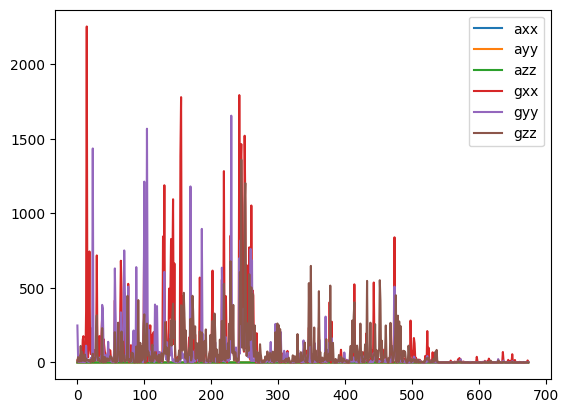

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xlrd

wb=pd.read_excel("/content/Caracteristicas.xlsx",header=0)

clases=np.array(wb.Suelo)
axx=np.array(wb.Varianza_aX)
ayy=np.array(wb.Varianza_aY)
azz=np.array(wb.Varianza_aZ)
gxx=np.array(wb.Varianza_gX)
gyy=np.array(wb.Varianza_gY)
gzz=np.array(wb.Varianza_gZ)

plt.plot(axx)
plt.plot(ayy)
plt.plot(azz)
plt.plot(gxx)
plt.plot(gyy)
plt.plot(gzz)
plt.legend(['axx','ayy','azz','gxx','gyy','gzz'])